# Machine learning : Déchets

Prédire la production de déchets ménagers par habitant et par département (données ADEME / SINOE et INSEE).

**ALVES Rudy, ANTHONY Josselin, BENASSIE Noé, TAVERNIER Florian** — iRUP Alternance, module DataScience & Machine Learning.

Ce notebook rejoue tout le projet, étape par étape. Il fonctionne **dans Google Colab** comme dans Jupyter en local : lancez les cellules dans l'ordre (*Exécution > Tout exécuter* dans Colab). Le rapport complet est dans `dechets/rapport/rapport_ML_dechets.pdf` du [dépôt GitHub](https://github.com/Rxdy/ML-DMA).

## 0. Préparer l'environnement

Dans Colab, cette cellule télécharge le dépôt (données comprises) et se place dans le dossier `dechets/`. En local, elle se place simplement dans ce dossier.

In [ ]:
import os
import subprocess

DEPOT = "https://github.com/Rxdy/ML-DMA.git"

if os.path.exists("scripts/09_pipeline.py"):            # déjà dans dechets/
    pass
elif os.path.exists("../scripts/09_pipeline.py"):       # lancé depuis dechets/notebooks/
    os.chdir("..")
else:                                                   # Colab ou dossier vide : on télécharge le dépôt
    if not os.path.exists("ML-DMA"):
        subprocess.run(["git", "clone", "--quiet", DEPOT], check=True)
    os.chdir("ML-DMA/dechets")

print("Dossier de travail :", os.getcwd())

In [ ]:
# Dépendances (déjà présentes dans Colab : l'installation ne fait que vérifier les versions)
%pip install --quiet -r ../requirements.txt

## 1. Exploration de la source principale (SINOE)

Dimensions, types, valeurs manquantes, doublons (lignes identiques et clés répétées), valeurs nulles.

In [3]:
%run scripts/01_explore.py

=== Dimensions ===
(14660, 10)

=== Colonnes et types ===
ANNEE                  int64
C_REGION               int64
L_REGION                 str
C_DEPT                   str
N_DEPT                   str
C_TYP_REG_DECHET         str
L_TYP_REG_DECHET         str
C_TYP_REG_SERVICE        str
L_TYP_REG_SERVICE        str
TONNAGE_DMA          float64
dtype: object

=== Aperçu ===
   ANNEE  C_REGION              L_REGION C_DEPT N_DEPT C_TYP_REG_DECHET  \
0   2009        84  Auvergne-Rhône-Alpes     01    Ain              07A   
1   2009        84  Auvergne-Rhône-Alpes     01    Ain              07A   
2   2009        84  Auvergne-Rhône-Alpes     01    Ain              07E   
3   2009        84  Auvergne-Rhône-Alpes     01    Ain              07E   
4   2009        84  Auvergne-Rhône-Alpes     01    Ain              07E   

                L_TYP_REG_DECHET C_TYP_REG_SERVICE  \
0  Ordures ménagères résiduelles               02B   
1  Ordures ménagères résiduelles               02D   
2        

## 2. Profil de traitement et clustering

Chaque département est décrit par la part de ses déchets partie en incinération, recyclage, stockage… Un k-means forme 4 groupes, utilisés ensuite comme variable d'entrée.

In [4]:
%run scripts/02_clustering_profil_traitement.py

=== Profil de traitement (%) par département ===
L_TYP_REG_SERVICE C_DEPT                   N_DEPT  C_REGION  \
0                     01                      Ain        84   
1                     02                    Aisne        32   
2                     03                   Allier        84   
3                     04  Alpes-de-Haute-Provence        93   
4                     05             Hautes-Alpes        93   

L_TYP_REG_SERVICE                    L_REGION  \
0                        Auvergne-Rhône-Alpes   
1                             Hauts-de-France   
2                        Auvergne-Rhône-Alpes   
3                  Provence-Alpes-Côte d'Azur   
4                  Provence-Alpes-Côte d'Azur   

L_TYP_REG_SERVICE  Incinération avec récupération d'énergie  \
0                                                 27.423810   
1                                                  1.244181   
2                                                 16.298202   
3                        

## 3. Préparation du jeu de régression

Jointure avec le cluster (contrôlée contre les doublons) et variables d'historique : la valeur de l'enquête précédente.

In [5]:
%run scripts/03_regression_prep.py

=== Shape avant traitement === (800, 9)

=== Valeurs manquantes ===
C_REGION       0
L_REGION       0
C_DEPT         0
N_DEPT         0
RATIO_DMA      0
ANNEE          0
TONNAGE_DMA    0
VA_POPANNEE    0
cluster        0
dtype: int64

Départements sans cluster de traitement : []

=== Aperçu final ===
     C_REGION              L_REGION C_DEPT N_DEPT  RATIO_DMA  ANNEE  \
0          84  Auvergne-Rhône-Alpes     01    Ain     487.50   2009   
100        84  Auvergne-Rhône-Alpes     01    Ain     490.83   2011   
200        84  Auvergne-Rhône-Alpes     01    Ain     475.55   2013   
300        84  Auvergne-Rhône-Alpes     01    Ain     459.54   2015   
401        84  Auvergne-Rhône-Alpes     01    Ain     461.93   2017   
502        84  Auvergne-Rhône-Alpes     01    Ain     471.29   2019   
602        84  Auvergne-Rhône-Alpes     01    Ain     503.65   2021   
701        84  Auvergne-Rhône-Alpes     01    Ain     463.87   2023   
1          32       Hauts-de-France     02  Aisne     509.0

## 4. Corrélations

Le ratio de l'enquête précédente est très corrélé à la cible (0,91), l'année presque pas (0,02).

=== Matrice de corrélation ===
                  ANNEE  VA_POPANNEE  cluster  RATIO_DMA_lag1  \
ANNEE              1.00         0.03     0.00            0.09   
VA_POPANNEE        0.03         1.00     0.23           -0.16   
cluster            0.00         0.23     1.00            0.14   
RATIO_DMA_lag1     0.09        -0.16     0.14            1.00   
TONNAGE_DMA_lag1   0.03         0.97     0.25            0.05   
TONNAGE_DMA        0.02         0.97     0.25            0.05   
RATIO_DMA          0.02        -0.17     0.13            0.91   

                  TONNAGE_DMA_lag1  TONNAGE_DMA  RATIO_DMA  
ANNEE                         0.03         0.02       0.02  
VA_POPANNEE                   0.97         0.97      -0.17  
cluster                       0.25         0.25       0.13  
RATIO_DMA_lag1                0.05         0.05       0.91  
TONNAGE_DMA_lag1              1.00         1.00       0.01  
TONNAGE_DMA                   1.00         1.00       0.05  
RATIO_DMA            


Heatmap sauvegardée -> data/figures/correlation_matrix.png


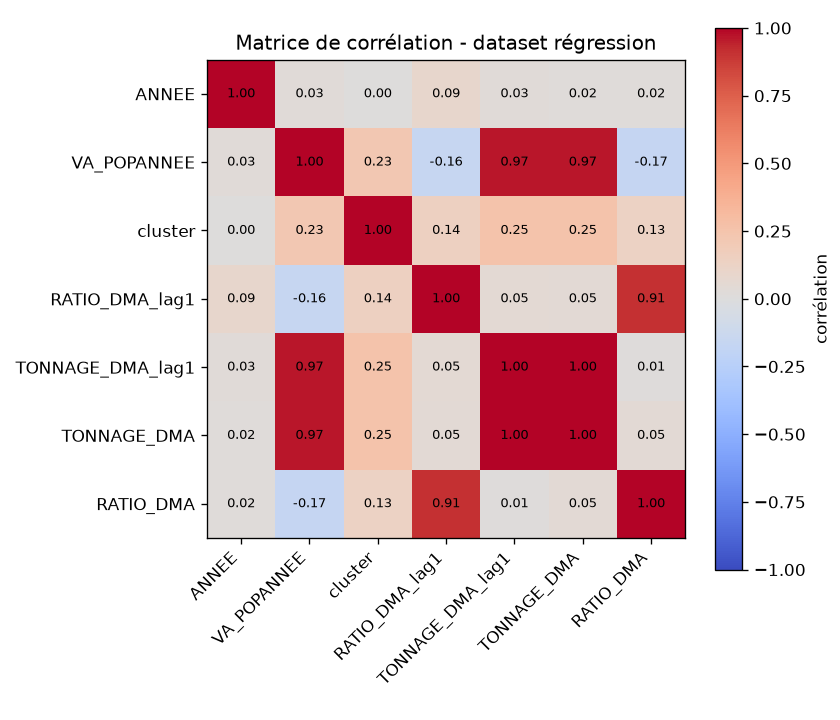

In [6]:
%run scripts/04_correlation.py
from IPython.display import Image, display
display(Image("data/figures/correlation_matrix.png", width=600))

## 5. Découpage par année et mise à l'échelle (version manuelle)

Entraînement sur 2011–2019, test sur 2021 et 2023. Le `MinMaxScaler` est calibré sur l'entraînement seul.

In [7]:
%run scripts/05_split_scale.py

Shape après suppression des lignes sans lag (2009) : (699, 11)
Train (<=2019) : 501 lignes, années [np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2017), np.int64(2019)]
Test  (>2019)  : 198 lignes, années [np.int64(2021), np.int64(2023)]
Couples département × année présents dans les deux jeux : 0

=== Avant scaling (train) ===
     VA_POPANNEE  cluster  RATIO_DMA_lag1  TONNAGE_DMA_lag1
min      76309.0      0.0          248.07          37785.06
max    2608346.0      3.0          885.16        1454047.96

=== Après scaling (train) : doit être exactement [0, 1] ===
     VA_POPANNEE  cluster  RATIO_DMA_lag1  TONNAGE_DMA_lag1
min          0.0      0.0             0.0               0.0
max          1.0      1.0             1.0               1.0

=== Après scaling (test) : peut dépasser [0, 1] si min/max du test diffèrent du train ===
     VA_POPANNEE  cluster  RATIO_DMA_lag1  TONNAGE_DMA_lag1
min     0.000070      0.0        0.216830          0.001638
max     1.002879      1.0   

## 6. Baseline et premiers modèles (version manuelle)

In [8]:
%run scripts/06_train_model.py

=== Évaluation sur le test (2021 + 2023) ===

Baseline naïve (= enquête précédente) MAE=  36.49 kg/hab   RMSE=  44.58 kg/hab   R2=0.702
Régression linéaire                 MAE=  35.89 kg/hab   RMSE=  43.64 kg/hab   R2=0.715


Random Forest                       MAE=  36.05 kg/hab   RMSE=  44.21 kg/hab   R2=0.707

=== Importance des variables (Random Forest) ===
RATIO_DMA_lag1      0.949
TONNAGE_DMA_lag1    0.018
VA_POPANNEE         0.017
cluster             0.015
dtype: float64

=== Erreur absolue moyenne (Random Forest) par cluster de traitement ===
              mean  count
cluster_raw              
0            33.58     82
1            37.62    104
2            39.17      2
3            39.33     10

Sauvegardé -> data/processed/test_predictions.csv, data/processed/model_comparison.csv


## 7. Une variable de plus : le revenu médian

Hypothèse testée et écartée : le revenu n'améliore pas la prédiction.

In [9]:
%run scripts/08_income_experiment.py

Lignes après jointure avec le revenu (années 2013-2021 seulement) : 490
Lignes après retrait de la 1ère année sans lag (2013) : 390
Années disponibles : [np.int64(2015), np.int64(2017), np.int64(2019), np.int64(2021)]
Train (<=2017) : 194 lignes | Test (>2017) : 196 lignes

=== A) SANS revenu (features d'origine) ===
  [sans revenu       ] Régression linéaire  MAE=  19.86  RMSE=  27.86  R2=0.887


  [sans revenu       ] Random Forest        MAE=  22.63  RMSE=  31.64  R2=0.854

=== B) AVEC revenu ===
  [avec revenu       ] Régression linéaire  MAE=  20.17  RMSE=  28.10  R2=0.885


  [avec revenu       ] Random Forest        MAE=  23.17  RMSE=  32.78  R2=0.844

=== Baseline naïve (recopier l'enquête précédente), sur ces mêmes lignes ===
  Baseline naïve      MAE=  21.72  RMSE=  29.83  R2=0.871



=== Importance des variables (Random Forest, avec revenu) ===
RATIO_DMA_lag1_v2    0.945
REVENU_lag1          0.015
MEDIANE_REVENU       0.012
VA_POPANNEE          0.012
TONNAGE_DMA_lag1     0.009
cluster              0.007
dtype: float64


## 8. Preprocessor et pipeline — le modèle de référence

- **X** (entrées) : population, ratio et tonnage de l'enquête précédente, cluster ; **y** (sortie) : ratio de déchets par habitant.
- **Preprocessor** : `MinMaxScaler` sur les variables numériques, `OneHotEncoder` sur le cluster.
- **Pipeline** : preprocessor → modèle. Cinq approches comparées : baseline moyenne, baseline naïve, régression linéaire, arbre de décision, Random Forest.
- Évaluation : validation croisée temporelle sur 2013–2019, puis test sur 2021 et 2023.

In [10]:
%run scripts/09_pipeline.py

Train : 501 lignes (2011-2019) | Test : 198 lignes (2021, 2023)

=== Validation croisée temporelle (train seul, 4 plis : valide 2013, 2015, 2017, 2019) ===
Baseline naïve (= enquête précédente) MAE= 18.68  R2=0.872 (± 0.043)
Baseline moyenne (DummyRegressor)   MAE= 62.23  R2=-0.013 (± 0.009)
Régression linéaire                 MAE= 19.55  R2=0.865 (± 0.039)
Arbre de décision                   MAE= 21.85  R2=0.840 (± 0.049)


Random Forest                       MAE= 20.88  R2=0.845 (± 0.045)

=== Évaluation sur le test (2021 + 2023) ===



Gain de MAE régression linéaire vs baseline naïve : 0.74 kg/hab (IC 95 % : 0.14 à 1.34), meilleure sur 54% des départements-années
Baseline naïve (= enquête précédente)  MAE= 36.49  RMSE= 44.58  R2=0.702
Baseline moyenne (DummyRegressor)      MAE= 61.99  RMSE= 82.14  R2=-0.010
Régression linéaire                    MAE= 35.75  RMSE= 43.53  R2=0.716
Arbre de décision                      MAE= 37.04  RMSE= 45.58  R2=0.689
Random Forest                          MAE= 36.08  RMSE= 44.36  R2=0.705

Colonnes en sortie du preprocessor : ['num__VA_POPANNEE', 'num__RATIO_DMA_lag1', 'num__TONNAGE_DMA_lag1', 'cat__cluster_0', 'cat__cluster_1', 'cat__cluster_2', 'cat__cluster_3']

=== Importance des variables (Random Forest) ===
num__RATIO_DMA_lag1      0.949
num__TONNAGE_DMA_lag1    0.019
num__VA_POPANNEE         0.017
cat__cluster_3           0.009
cat__cluster_2           0.004
cat__cluster_1           0.002
cat__cluster_0           0.001
dtype: float64

Sauvegardé -> data/processed/model_compa

In [11]:
# Tableau récapitulatif du test (variables créées par le script précédent)
res.round(3)

,modele,MAE,RMSE,R2
0,Baseline naïve (= enquête précédente),36.489,44.581,0.702
1,Baseline moyenne (DummyRegressor),61.991,82.145,-0.010
2,Régression linéaire,35.752,43.533,0.716
3,Arbre de décision,37.036,45.578,0.689
4,Random Forest,36.084,44.365,0.705


## 9. Détail des calculs

MAE, RMSE et R² calculés pas à pas, pli par pli, année par année ; choix de la profondeur de l'arbre de décision (surapprentissage).

In [12]:
%run scripts/10_detail_metriques.py

=== Test 2021 + 2023 : calcul pas à pas ===

Baseline moyenne
  MAE  = 12274.2 / 198 = 61.99 kg/hab
  RMSE = sqrt(1336053 / 198) = 82.14 kg/hab
  R²   = 1 - 1336053 / 1322733 = -0.010

Baseline naïve
  MAE  = 7224.8 / 198 = 36.49 kg/hab
  RMSE = sqrt(393520 / 198) = 44.58 kg/hab
  R²   = 1 - 393520 / 1322733 = 0.702

Régression linéaire
  MAE  = 7078.8 / 198 = 35.75 kg/hab
  RMSE = sqrt(375240 / 198) = 43.53 kg/hab
  R²   = 1 - 375240 / 1322733 = 0.716

Arbre de décision
  MAE  = 7333.1 / 198 = 37.04 kg/hab
  RMSE = sqrt(411313 / 198) = 45.58 kg/hab
  R²   = 1 - 411313 / 1322733 = 0.689

Random Forest
  MAE  = 7144.6 / 198 = 36.08 kg/hab
  RMSE = sqrt(389706 / 198) = 44.36 kg/hab
  R²   = 1 - 389706 / 1322733 = 0.705

=== Exemple : 3 départements en 2023 (régression linéaire) ===
        RATIO_DMA_lag1  RATIO_DMA   pred  erreur
N_DEPT                                          
Ain              503.6      463.9  504.5   -40.6
Landes           891.6      811.6  883.4   -71.8
Paris        


=== Validation croisée, pli par pli ===
modele         Arbre de décision  Baseline moyenne  Baseline naïve  Random Forest  Régression linéaire
annee_validee                                                                                         
2013                       0.803            -0.029           0.815          0.819                0.812
2015                       0.848            -0.007           0.850          0.808                0.856
2017                       0.792            -0.007           0.895          0.831                0.872
2019                       0.917            -0.011           0.927          0.921                0.920
                        MAE    RMSE     R2
modele                                    
Arbre de décision    21.850  31.685  0.840
Baseline moyenne     62.235  81.042 -0.013
Baseline naïve       18.684  28.196  0.872
Random Forest        20.877  31.172  0.845
Régression linéaire  19.545  29.086  0.865

=== Test, année par année ===
         


=== Arbre de décision : R² selon la profondeur ===
profondeur  R2_entrainement  R2_validation_croisee  R2_test
         2            0.779                  0.728    0.577
         3            0.871                  0.824    0.653
         4            0.903                  0.840    0.689
         5            0.925                  0.836    0.683
         6            0.952                  0.817    0.605
         8            0.971                  0.756    0.613
 illimitée            1.000                  0.755    0.573

Sauvegardé -> data/processed/detail_*.csv


## 10. Analyse des erreurs

L'erreur est surtout commune à tous les départements : il manque une information qui évolue dans le temps, d'abord au niveau national.

In [13]:
%run scripts/11_analyse_erreurs.py

=== Erreur moyenne par année (> 0 = le modèle surestime) ===
       moyenne  ecart_type
ANNEE                     
2021     -21.6        27.8
2023      42.7        27.3
2021 : évolution moyenne +21.5 kg/hab, 11% des départements en baisse
2023 : évolution moyenne -43.8 kg/hab, 97% des départements en baisse

=== Valeur d'une information nationale ===
Baseline naïve                       MAE= 36.49  R2=0.702
Régression linéaire                  MAE= 35.75  R2=0.716
Naïve + évolution nationale connue   MAE= 19.89  R2=0.881

=== Les 10 plus grosses erreurs ===
               N_DEPT  ANNEE  RATIO_DMA_lag1  RATIO_DMA  prediction  erreur
         Eure-et-Loir   2023           609.0      454.0       607.0   152.0
         Corse-du-Sud   2023           770.0      635.0       762.0   127.0
Territoire-de-Belfort   2023           603.0      479.0       603.0   124.0
                 Oise   2023           607.0      492.0       603.0   111.0
        Pas-de-Calais   2021           553.0      652.0 

## Conclusion

La règle « comme à l'enquête précédente » prédit déjà le ratio à environ 36 kg/hab près sur des années jamais vues ; nos modèles la retrouvent sans la dépasser de façon utile. Les écarts entre départements sont durables, et ce qui change d'une enquête à l'autre est surtout un mouvement national. Détails, interprétation et pistes d'amélioration : voir le rapport PDF.